# WEEK 1 : Data Collection, Text Cleaning, and EDA

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("NYC311data.csv", nrows = 10000)
df

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01-01-16 0:55,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01-01-16 1:26,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01-01-16 4:51,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01-01-16 7:43,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01-01-16 3:24,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,32242311,12/20/2015 05:35:22 PM,12/20/2015 07:38:43 PM,NYPD,New York City Police Department,Illegal Parking,Double Parked Blocking Vehicle,Street/Sidewalk,10029.0,1760 3 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.786143,-73.948646,"(40.78614262952058, -73.94864628750543)"
9996,32240903,12/20/2015 05:33:03 PM,12/21/2015 02:01:44 AM,NYPD,New York City Police Department,Blocked Driveway,Partial Access,Street/Sidewalk,11226.0,931 OCEAN AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.639955,-73.959078,"(40.639955333814946, -73.95907837917537)"
9997,32241322,12/20/2015 05:32:39 PM,12/20/2015 06:19:47 PM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11218.0,1343 40 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.639476,-73.985879,"(40.6394759209015, -73.98587913404236)"
9998,32240998,12/20/2015 05:30:31 PM,12/20/2015 06:41:50 PM,NYPD,New York City Police Department,Homeless Encampment,NaN,Street/Sidewalk,10036.0,432 WEST 45 STREET,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.760913,-73.992578,"(40.76091321982277, -73.99257835358914)"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      10000 non-null  int64  
 1   Created Date                    10000 non-null  object 
 2   Closed Date                     9943 non-null   object 
 3   Agency                          10000 non-null  object 
 4   Agency Name                     10000 non-null  object 
 5   Complaint Type                  10000 non-null  object 
 6   Descriptor                      9822 non-null   object 
 7   Location Type                   10000 non-null  object 
 8   Incident Zip                    9934 non-null   float64
 9   Incident Address                8893 non-null   object 
 10  Street Name                     8893 non-null   object 
 11  Cross Street 1                  8752 non-null   object 
 12  Cross Street 2                  8

In [4]:
df.isnull().sum()

Unique Key                            0
Created Date                          0
Closed Date                          57
Agency                                0
Agency Name                           0
Complaint Type                        0
Descriptor                          178
Location Type                         0
Incident Zip                         66
Incident Address                   1107
Street Name                        1107
Cross Street 1                     1248
Cross Street 2                     1264
Intersection Street 1              8899
Intersection Street 2              8913
Address Type                         72
City                                 66
Landmark                           9994
Facility Type                        55
Status                                0
Due Date                              0
Resolution Description                0
Resolution Action Updated Date       55
Community Board                       0
Borough                               0


In [5]:
df['Complaint Type'].unique()

array(['Noise - Street/Sidewalk', 'Blocked Driveway', 'Illegal Parking',
       'Derelict Vehicle', 'Noise - Commercial',
       'Noise - House of Worship', 'Posting Advertisement',
       'Noise - Vehicle', 'Animal Abuse', 'Vending', 'Traffic',
       'Drinking', 'Bike/Roller/Skate Chronic', 'Panhandling',
       'Noise - Park', 'Homeless Encampment', 'Urinating in Public',
       'Graffiti', 'Disorderly Youth'], dtype=object)

In [6]:
df = df[['Complaint Type','Descriptor','Borough','Agency Name']]
print(df)
df.shape

               Complaint Type                      Descriptor    Borough  \
0     Noise - Street/Sidewalk                Loud Music/Party  MANHATTAN   
1            Blocked Driveway                       No Access     QUEENS   
2            Blocked Driveway                       No Access      BRONX   
3             Illegal Parking    Commercial Overnight Parking      BRONX   
4             Illegal Parking                Blocked Sidewalk     QUEENS   
...                       ...                             ...        ...   
9995          Illegal Parking  Double Parked Blocking Vehicle  MANHATTAN   
9996         Blocked Driveway                  Partial Access   BROOKLYN   
9997         Blocked Driveway                       No Access   BROOKLYN   
9998      Homeless Encampment                             NaN  MANHATTAN   
9999          Illegal Parking   Posted Parking Sign Violation  MANHATTAN   

                          Agency Name  
0     New York City Police Department  
1     N

(10000, 4)

In [7]:
df = df.dropna(subset = ['Descriptor','Complaint Type'])
df.shape

(9822, 4)

In [8]:
df = df[df['Borough'] != 'Unspecified']
print("Shape after removing Unspecified borough:", df.shape)

Shape after removing Unspecified borough: (9756, 4)


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

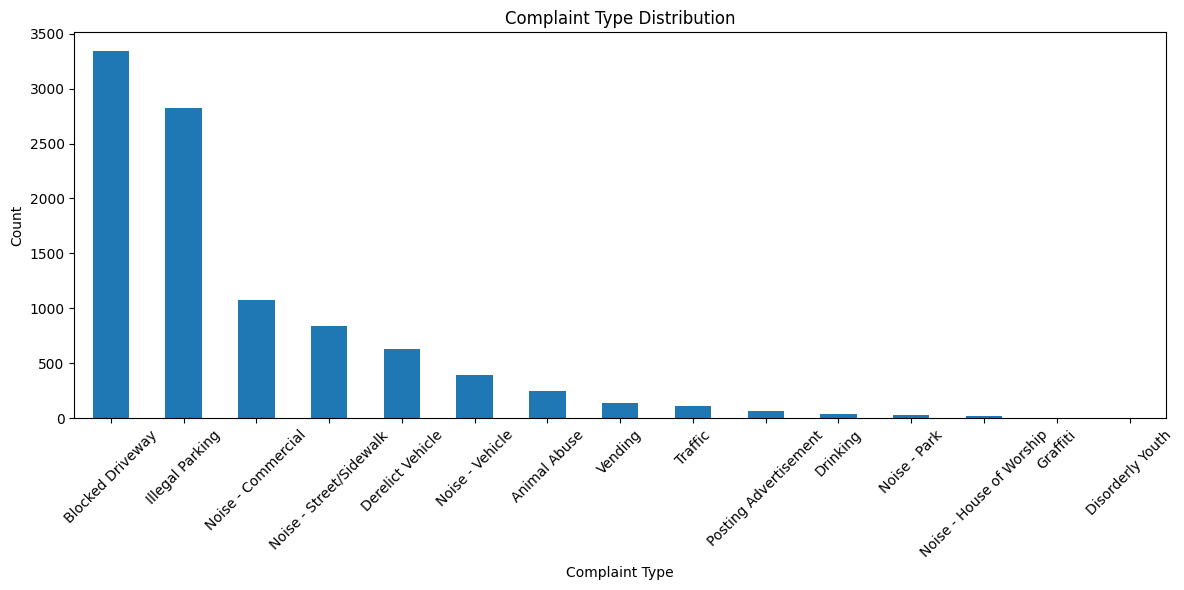

In [10]:
df['Complaint Type'].value_counts().plot(kind = 'bar', figsize = (12,6))
plt.title('Complaint Type Distribution')
plt.xlabel('Complaint Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
top10 = df['Complaint Type'].value_counts().head(10).index
df = df[df['Complaint Type'].isin(top10)]
df['Complaint Type'].value_counts()

Complaint Type
Blocked Driveway           3345
Illegal Parking            2825
Noise - Commercial         1077
Noise - Street/Sidewalk     836
Derelict Vehicle            630
Noise - Vehicle             390
Animal Abuse                249
Vending                     137
Traffic                     110
Posting Advertisement        62
Name: count, dtype: int64

In [12]:
df['Text_length'] = df['Descriptor'].apply(len)
df['Text_length'].describe()

count    9661.000000
mean       15.955595
std         6.802325
min         6.000000
25%         9.000000
50%        15.000000
75%        18.000000
max        30.000000
Name: Text_length, dtype: float64

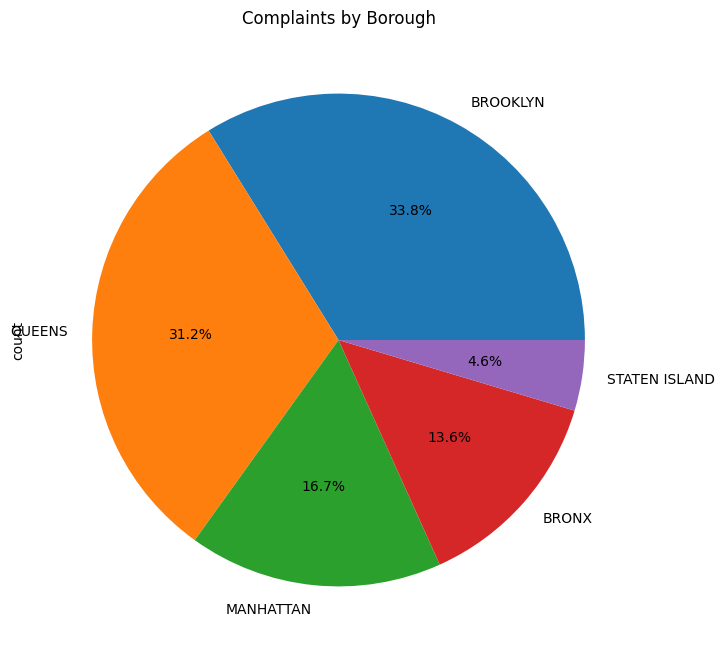

In [13]:
df['Borough'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(8,8))
plt.title('Complaints by Borough')
plt.show()

In [14]:
df['clean_text'] = df['Descriptor'].str.lower()

In [15]:
import re
df['clean_text'] = df['clean_text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

In [16]:
df.head(10)

,Complaint Type,Descriptor,Borough,Agency Name,Text_length,clean_text
0,Noise - Street/Sidewalk,Loud Music/Party,MANHATTAN,New York City Police Department,16,loud musicparty
1,Blocked Driveway,No Access,QUEENS,New York City Police Department,9,no access
2,Blocked Driveway,No Access,BRONX,New York City Police Department,9,no access
3,Illegal Parking,Commercial Overnight Parking,BRONX,New York City Police Department,28,commercial overnight parking
4,Illegal Parking,Blocked Sidewalk,QUEENS,New York City Police Department,16,blocked sidewalk
5,Illegal Parking,Posted Parking Sign Violation,BROOKLYN,New York City Police Department,29,posted parking sign violation
6,Illegal Parking,Blocked Hydrant,MANHATTAN,New York City Police Department,15,blocked hydrant
7,Blocked Driveway,No Access,BRONX,New York City Police Department,9,no access
8,Illegal Parking,Posted Parking Sign Violation,QUEENS,New York City Police Department,29,posted parking sign violation
9,Blocked Driveway,No Access,BROOKLYN,New York City Police Department,9,no access


In [17]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\RAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\RAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [18]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
negations = {'no', 'not', 'never', 'neither', 'nor'}
stop_words = stop_words - negations

df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

In [19]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))

In [20]:
df[['Descriptor', 'clean_text']].head(10)

,Descriptor,clean_text
0,Loud Music/Party,loud musicparty
1,No Access,no access
2,No Access,no access
3,Commercial Overnight Parking,commercial overnight parking
4,Blocked Sidewalk,blocked sidewalk
5,Posted Parking Sign Violation,posted parking sign violation
6,Blocked Hydrant,blocked hydrant
7,No Access,no access
8,Posted Parking Sign Violation,posted parking sign violation
9,No Access,no access


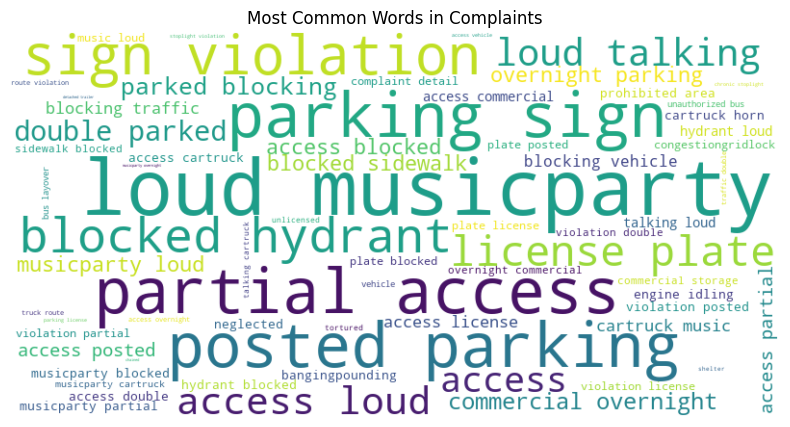

In [21]:
from wordcloud import WordCloud

text = ' '.join(df['clean_text'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Complaints')
plt.show()

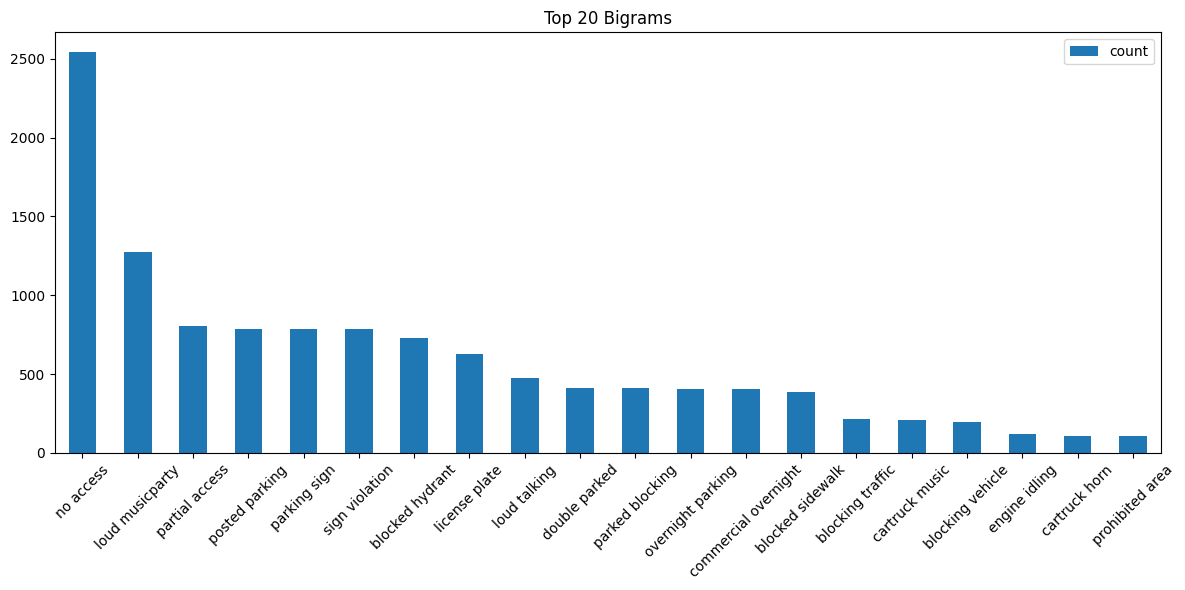

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vectorizer.fit_transform(df['clean_text'])

bigram_df = pd.DataFrame(X.toarray().sum(axis=0),index=vectorizer.get_feature_names_out(),columns=['count']).sort_values('count', ascending=False)

bigram_df.plot(kind='bar', figsize=(12,6))
plt.title('Top 20 Bigrams')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEK 2 :  Topic Modeling and Department Categorization

In [23]:
# Define Features and Target
X = df['clean_text']
y = df['Complaint Type']

print('Total samples: ',len(X))
print('Total classes: ', y.unique())
print('\nClass distribution: ')
print(y.value_counts())

Total samples:  9661
Total classes:  ['Noise - Street/Sidewalk' 'Blocked Driveway' 'Illegal Parking'
 'Derelict Vehicle' 'Noise - Commercial' 'Posting Advertisement'
 'Noise - Vehicle' 'Animal Abuse' 'Vending' 'Traffic']

Class distribution: 
Complaint Type
Blocked Driveway           3345
Illegal Parking            2825
Noise - Commercial         1077
Noise - Street/Sidewalk     836
Derelict Vehicle            630
Noise - Vehicle             390
Animal Abuse                249
Vending                     137
Traffic                     110
Posting Advertisement        62
Name: count, dtype: int64


In [24]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify = y)

print('Training samples: ', len(X_train))
print('Testing samples: ', len(y_test))

Training samples:  7728
Testing samples:  1933


In [25]:
# TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF matrix shape (train): ',X_train_tfidf.shape)
print('TF-IDF matrix shape (test): ', X_test_tfidf.shape)

TF-IDF matrix shape (train):  (7728, 85)
TF-IDF matrix shape (test):  (1933, 85)


In [26]:
# Model 1: Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)
nb_f1 = f1_score(y_test, nb_pred, average='macro')

print('=== Naive Bayes ===')
print(f'Macro F1 Score: {nb_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, nb_pred))

=== Naive Bayes ===
Macro F1 Score: 0.8274

Classification Report:
                         precision    recall  f1-score   support

           Animal Abuse       1.00      1.00      1.00        50
       Blocked Driveway       1.00      1.00      1.00       669
       Derelict Vehicle       1.00      1.00      1.00       126
        Illegal Parking       0.98      1.00      0.99       565
     Noise - Commercial       0.68      0.83      0.75       216
Noise - Street/Sidewalk       0.76      0.49      0.60       167
        Noise - Vehicle       0.89      1.00      0.94        78
  Posting Advertisement       0.00      0.00      0.00        12
                Traffic       1.00      1.00      1.00        22
                Vending       1.00      1.00      1.00        28

               accuracy                           0.93      1933
              macro avg       0.83      0.83      0.83      1933
           weighted avg       0.93      0.93      0.93      1933



C:\Users\RAJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\RAJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\RAJ\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

In [27]:
# Model 2: LinearSVC
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight='balanced',max_iter=2000,random_state=42)
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)
svm_f1 = f1_score(y_test, svm_pred, average='macro')

print('=== LinearSVC ===')
print(f'Macro F1 Score: {svm_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, svm_pred))

=== LinearSVC ===
Macro F1 Score: 0.9285

Classification Report:
                         precision    recall  f1-score   support

           Animal Abuse       1.00      1.00      1.00        50
       Blocked Driveway       1.00      1.00      1.00       669
       Derelict Vehicle       1.00      1.00      1.00       126
        Illegal Parking       1.00      1.00      1.00       565
     Noise - Commercial       0.68      0.83      0.75       216
Noise - Street/Sidewalk       0.76      0.49      0.60       167
        Noise - Vehicle       0.89      1.00      0.94        78
  Posting Advertisement       1.00      1.00      1.00        12
                Traffic       1.00      1.00      1.00        22
                Vending       1.00      1.00      1.00        28

               accuracy                           0.94      1933
              macro avg       0.93      0.93      0.93      1933
           weighted avg       0.94      0.94      0.93      1933



In [28]:
# Model 3: Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)
lr_f1 = f1_score(y_test, lr_pred, average='macro')

print('=== Logistic Regression ===')
print(f'Macro F1 Score: {lr_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Macro F1 Score: 0.9285

Classification Report:
                         precision    recall  f1-score   support

           Animal Abuse       1.00      1.00      1.00        50
       Blocked Driveway       1.00      1.00      1.00       669
       Derelict Vehicle       1.00      1.00      1.00       126
        Illegal Parking       1.00      1.00      1.00       565
     Noise - Commercial       0.68      0.83      0.75       216
Noise - Street/Sidewalk       0.76      0.49      0.60       167
        Noise - Vehicle       0.89      1.00      0.94        78
  Posting Advertisement       1.00      1.00      1.00        12
                Traffic       1.00      1.00      1.00        22
                Vending       1.00      1.00      1.00        28

               accuracy                           0.94      1933
              macro avg       0.93      0.93      0.93      1933
           weighted avg       0.94      0.94      0.93      1933



                 Model  Macro F1 Score
0            LinearSVC        0.928456
1  Logistic Regression        0.928456
2          Naive Bayes        0.827406


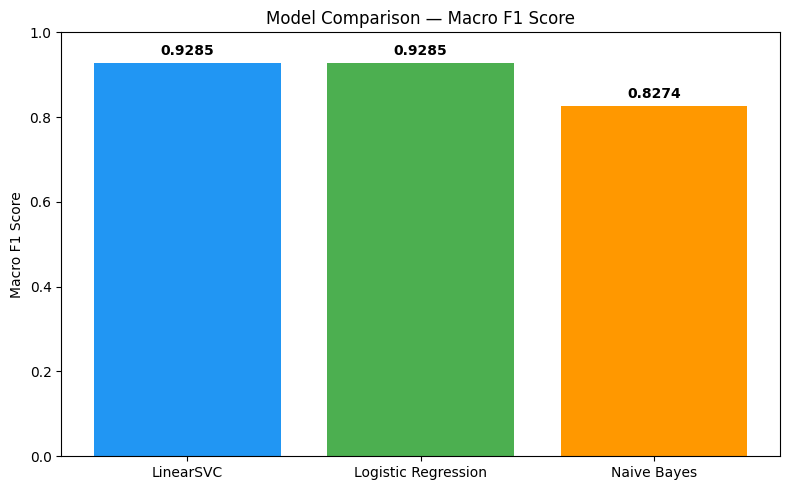

In [29]:
# Model comparison
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'LinearSVC', 'Logistic Regression'],
    'Macro F1 Score': [nb_f1, svm_f1, lr_f1]
})
results = results.sort_values('Macro F1 Score', ascending=False).reset_index(drop=True)
print(results)

plt.figure(figsize=(8, 5))
bars = plt.bar(results['Model'], results['Macro F1 Score'], color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Model Comparison — Macro F1 Score')
plt.ylabel('Macro F1 Score')
plt.ylim(0, 1)
for bar, val in zip(bars, results['Macro F1 Score']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Cross-Validation
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)),
    ('model', LinearSVC(class_weight='balanced', max_iter=2000, random_state=42))
])

cv_scores = cross_val_score(best_pipeline, X, y, cv=5, scoring='f1_macro')

print('Cross-Validation Macro F1 Scores (5 folds):')
for i, score in enumerate(cv_scores):
    print(f'  Fold {i+1}: {score:.4f}')
print(f'\nMean CV Score: {cv_scores.mean():.4f}')
print(f'Std Dev: {cv_scores.std():.4f}')

Cross-Validation Macro F1 Scores (5 folds):
  Fold 1: 0.9296
  Fold 2: 0.9196
  Fold 3: 0.9144
  Fold 4: 0.8982
  Fold 5: 0.9373

Mean CV Score: 0.9198
Std Dev: 0.0134


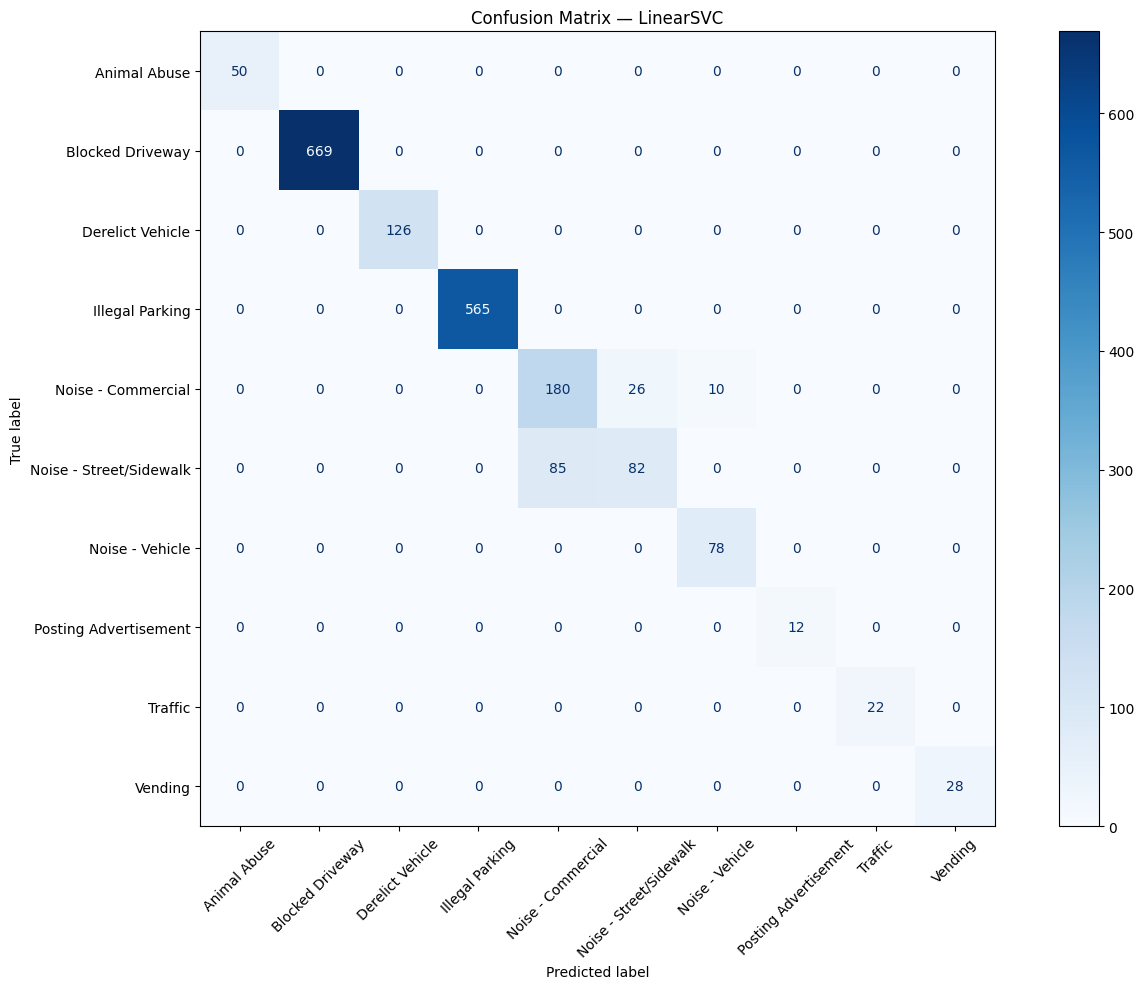

In [31]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, svm_pred, labels=svm_model.classes_)

plt.figure(figsize=(14, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(ax=plt.gca(), xticks_rotation=45, colorbar=True, cmap='Blues')
plt.title('Confusion Matrix — LinearSVC')
plt.tight_layout()
plt.show()

In [32]:
# Top TF-IDF Features Per Class
feature_names = tfidf.get_feature_names_out()

print('Top 5 TF-IDF features per complaint category:\n')
for i, class_label in enumerate(svm_model.classes_):
    top_indices = svm_model.coef_[i].argsort()[-5:][::-1]
    top_features = [feature_names[idx] for idx in top_indices]
    print(f'{class_label}: {top_features}')

Top 5 TF-IDF features per complaint category:

Animal Abuse: ['neglected', 'tortured', 'chained', 'car', 'shelter']
Blocked Driveway: ['access', 'partial access', 'partial', 'no access', 'no']
Derelict Vehicle: ['plate', 'license', 'license plate', 'blocking vehicle', 'sign']
Illegal Parking: ['blocked', 'parking', 'commercial', 'overnight', 'double parked']
Noise - Commercial: ['bangingpounding', 'loud television', 'television', 'loud', 'musicparty']
Noise - Street/Sidewalk: ['talking', 'loud talking', 'loud', 'loud musicparty', 'musicparty']
Noise - Vehicle: ['cartruck', 'idling', 'engine', 'engine idling', 'music']
Posting Advertisement: ['vehicle', 'building', 'traffic', 'blocking traffic', 'sign violation']
Traffic: ['congestiongridlock', 'chronic', 'chronic speeding', 'speeding', 'truck']
Vending: ['unlicensed', 'prohibited', 'area', 'prohibited area', 'blocking vehicle']


In [33]:
# Quick Prediction Test
test_complaints = [
    "loud music coming from next door apartment at night",
    "car is blocking my driveway since morning",
    "graffiti on the wall near the park"
]

test_tfidf = tfidf.transform(test_complaints)
predictions = svm_model.predict(test_tfidf)

print('Prediction Test:')
for complaint, pred in zip(test_complaints, predictions):
    print(f'  Input : "{complaint}"')
    print(f'  Predicted Dept: {pred}\n')

Prediction Test:
  Input : "loud music coming from next door apartment at night"
  Predicted Dept: Noise - Vehicle

  Input : "car is blocking my driveway since morning"
  Predicted Dept: Animal Abuse

  Input : "graffiti on the wall near the park"
  Predicted Dept: Illegal Parking



# WEEK 3 :  Sentiment Analysis and Urgency Scoring

In [34]:
!pip install textblob


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

In [36]:
# Sentiment Analysis using TextBlob
# TextBlob gives polarity: -1.0 (very negative) to +1.0 (very positive)
# Using original Descriptor text - preserves emotional signals

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

df['polarity'] = df['Descriptor'].apply(get_polarity)
df['subjectivity'] = df['Descriptor'].apply(get_subjectivity)

print('Polarity stats:')
print(df['polarity'].describe())

Polarity stats:
count    9661.000000
mean        0.008276
std         0.053789
min        -0.212500
25%         0.000000
50%         0.000000
75%         0.000000
max         0.100000
Name: polarity, dtype: float64


In [37]:
# Classify Sentiment into 4 categories as per project guidelines
# Positive, Neutral, Negative, Critical/Urgent

def classify_sentiment(polarity):
    if polarity < -0.5:
        return 'Critical/Urgent'
    elif polarity < 0:
        return 'Negative'
    elif polarity == 0:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['polarity'].apply(classify_sentiment)

print('Sentiment Distribution:')
print(df['sentiment'].value_counts())

Sentiment Distribution:
sentiment
Neutral     7039
Positive    1749
Negative     873
Name: count, dtype: int64


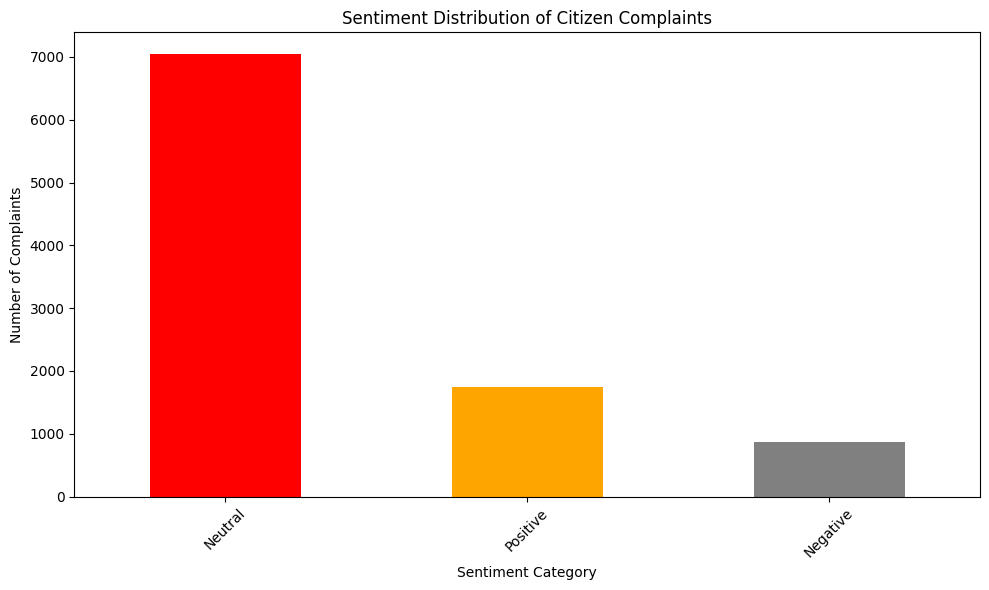

In [38]:
# Visualize Sentiment Distribution
colors = ['red', 'orange', 'gray', 'green']
df['sentiment'].value_counts().plot(kind='bar', figsize=(10, 6), color=colors)
plt.title('Sentiment Distribution of Citizen Complaints')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
# Mathematical Priority Score per ticket based on severity of sentiment
# Formula: Priority = 5 + (-polarity * 3) + (subjectivity * 2)
# Baseline = 5, more negative = higher score, more emotional = higher score
# Clipped between 1 and 10

df['priority_score'] = 5 + (-df['polarity'] * 3) + (df['subjectivity'] * 2)
df['priority_score'] = df['priority_score'].clip(1, 10).round(2)

print('Priority Score Statistics:')
print(df['priority_score'].describe())

Priority Score Statistics:
count    9661.000000
mean        5.318857
std         0.531141
min         5.000000
25%         5.000000
50%         5.000000
75%         5.900000
max         6.300000
Name: priority_score, dtype: float64


In [40]:
# Priority Labels
def assign_priority_label(score):
    if score >= 7:
        return 'High Priority'
    elif score >= 4:
        return 'Medium Priority'
    else:
        return 'Low Priority'

df['priority_label'] = df['priority_score'].apply(assign_priority_label)

print('Priority Label Distribution:')
print(df['priority_label'].value_counts())

Priority Label Distribution:
priority_label
Medium Priority    9661
Name: count, dtype: int64


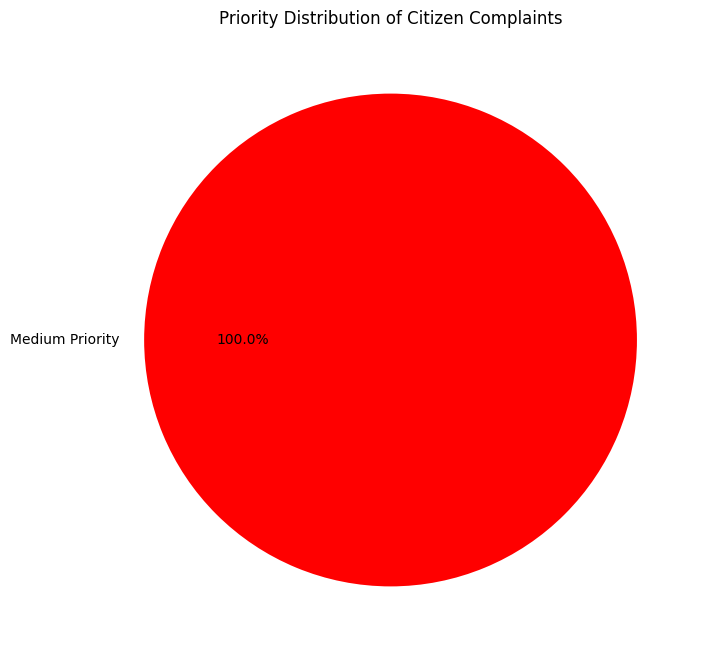

In [41]:
# Priority Distribution Pie Chart
df['priority_label'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    figsize=(8, 8), colors=['red', 'orange', 'green']
)
plt.title('Priority Distribution of Citizen Complaints')
plt.ylabel('')
plt.show()

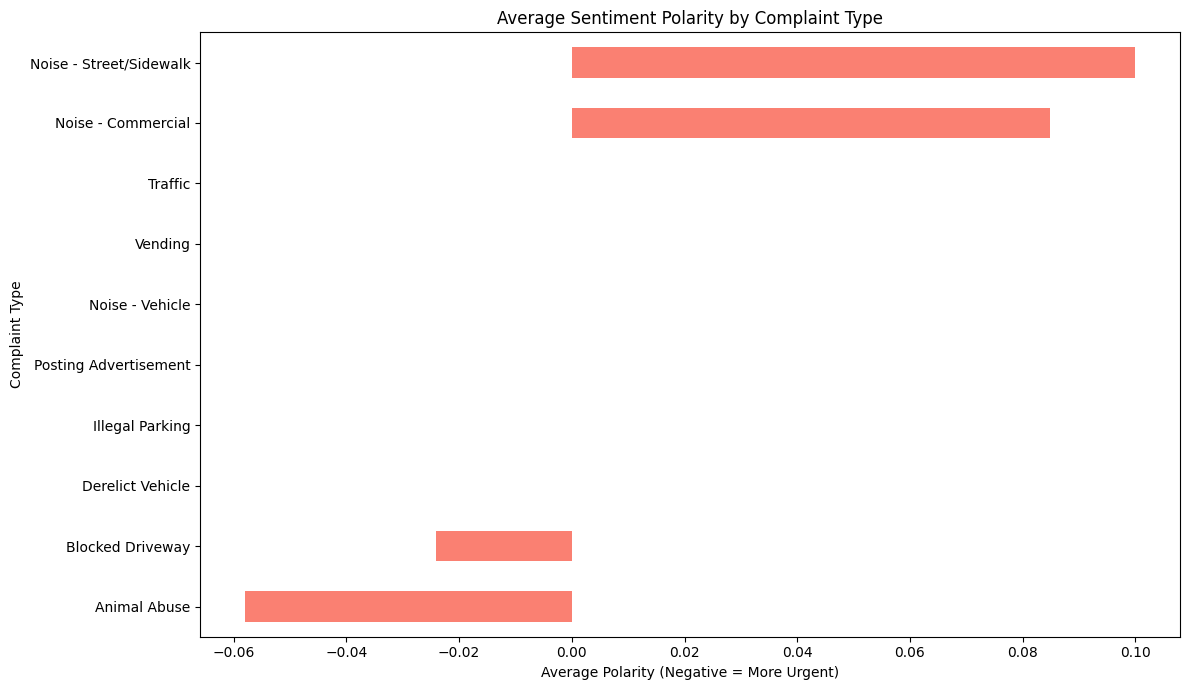

In [42]:
# Average Sentiment by Complaint Type
sentiment_by_type = df.groupby('Complaint Type')['polarity'].mean().sort_values()
sentiment_by_type.plot(kind='barh', figsize=(12, 7), color='salmon')
plt.title('Average Sentiment Polarity by Complaint Type')
plt.xlabel('Average Polarity (Negative = More Urgent)')
plt.tight_layout()
plt.show()

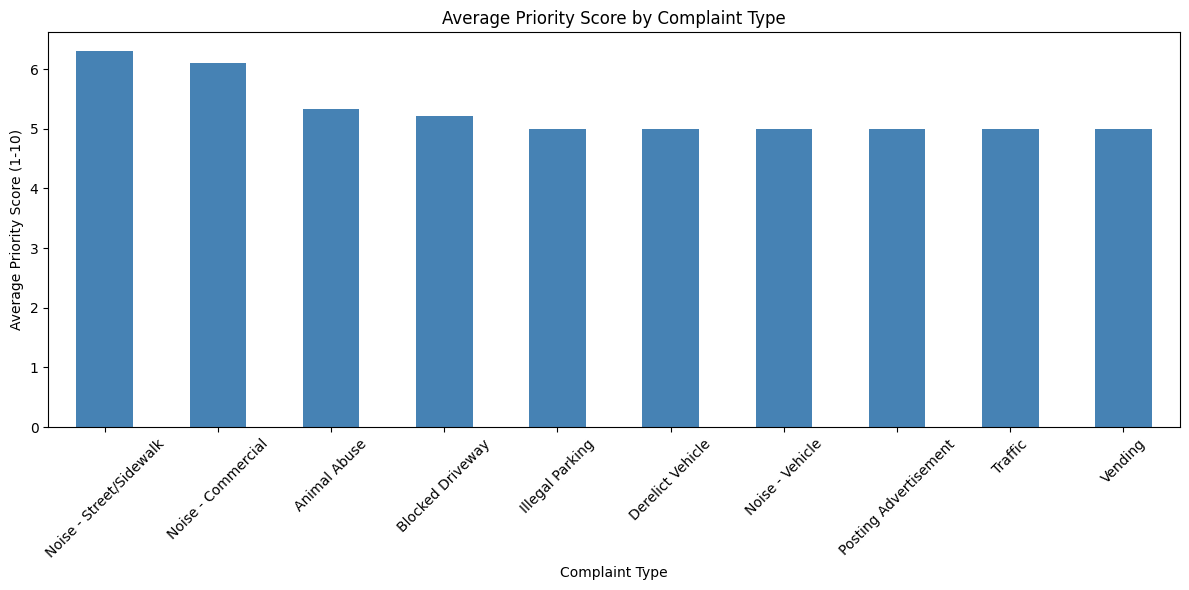

In [43]:
# Average Priority Score by Complaint Type
priority_by_type = df.groupby('Complaint Type')['priority_score'].mean().sort_values(ascending=False)
priority_by_type.plot(kind='bar', figsize=(12, 6), color='steelblue')
plt.title('Average Priority Score by Complaint Type')
plt.xlabel('Complaint Type')
plt.ylabel('Average Priority Score (1-10)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# Top 10 Most Critical Complaints
print('TOP 10 MOST CRITICAL COMPLAINTS')
print('='*70)
top_critical = df[['Descriptor','Complaint Type','sentiment','priority_score','priority_label']]\
    .sort_values('priority_score', ascending=False).head(10)
print(top_critical.to_string())

TOP 10 MOST CRITICAL COMPLAINTS
            Descriptor           Complaint Type sentiment  priority_score   priority_label
12    Loud Music/Party  Noise - Street/Sidewalk  Positive             6.3  Medium Priority
17    Loud Music/Party       Noise - Commercial  Positive             6.3  Medium Priority
0     Loud Music/Party  Noise - Street/Sidewalk  Positive             6.3  Medium Priority
18    Loud Music/Party       Noise - Commercial  Positive             6.3  Medium Priority
9990  Loud Music/Party       Noise - Commercial  Positive             6.3  Medium Priority
9970      Loud Talking       Noise - Commercial  Positive             6.3  Medium Priority
19    Loud Music/Party  Noise - Street/Sidewalk  Positive             6.3  Medium Priority
2744  Loud Music/Party       Noise - Commercial  Positive             6.3  Medium Priority
2769  Loud Music/Party       Noise - Commercial  Positive             6.3  Medium Priority
2787  Loud Music/Party       Noise - Commercial  Positive 